# DS4420 Project - Collaborative Filtering Model

Authors: Gavin Bond, Benjamin Kataoka, Preetish Paul

## User-User Collaborative Filtering

This notebook implements our user-user collaborative filtering model to predict how much developers trust AI generated output (AIAcc). We load the cleaned combined dataset exported from preprocessing.ipynb and build from there.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the cleaned combined dataset from preprocessing.ipynb
df = pd.read_csv("data/combined_survey.csv")

print("Shape:", df.shape)
print("Year breakdown:")
print(df["year"].value_counts())

Shape: (55118, 14)
Year breakdown:
year
2024    29379
2025    25739
Name: count, dtype: int64


### Target Encoding

We ordinally encode AIAcc on a 0 to 4 scale rather than binarizing like the NN does. CF predicts a continuous score from similar users so keeping the full range gives us richer signal to work with.

In [3]:
trust_map = {
    "Highly trust": 4,
    "Somewhat trust": 3,
    "Neither trust nor distrust": 2,
    "Somewhat distrust": 1,
    "Highly distrust": 0
}

df["AIAcc_encoded"] = df["AIAcc"].map(trust_map)

print("AIAcc distribution:")
print(df["AIAcc_encoded"].value_counts().sort_index())

AIAcc distribution:
AIAcc_encoded
0     7490
1    13536
2    13582
3    19144
4     1366
Name: count, dtype: int64


In [4]:
# Check missing values per column before deciding how to handle them
cols_to_check = ["YearsCode", "WorkExp", "Age", "DevType", "EdLevel", "OrgSize",
                 "AISelect", "AISent", "AIThreat", "RemoteWork", "AIComplex", "ICorPM"]

missing = df[cols_to_check].isna().sum()
pct = (missing / len(df) * 100).round(1)

print(f"Total rows: {len(df)}")
print()
print(pd.DataFrame({"missing": missing, "pct": pct}).to_string())
print()
print(f"Rows remaining if we drop all missing: {df[cols_to_check].dropna().shape[0]}")

Total rows: 55118

            missing   pct
YearsCode      1442   2.6
WorkExp       12908  23.4
Age               0   0.0
DevType        1275   2.3
EdLevel        1086   2.0
OrgSize        6783  12.3
AISelect         23   0.0
AISent           39   0.1
AIThreat        828   1.5
RemoteWork     5527  10.0
AIComplex       266   0.5
ICorPM        16259  29.5

Rows remaining if we drop all missing: 37868


### Feature Cleaning

We convert the numeric columns to numbers and drop any row that has a missing value in any feature column. This brings us from 55,118 to around 37,868 developers but every row is complete with no imputation. We also keep all category values intact rather than collapsing rare ones into an "Other" bucket.

In [5]:
numeric_cols = ["YearsCode", "WorkExp"]
categorical_cols = [
    "Age", "DevType", "EdLevel", "OrgSize",
    "AISelect", "AISent", "AIThreat", "RemoteWork",
    "AIComplex", "ICorPM"
]

# Convert numeric columns to numbers
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with any missing value across all feature columns
df = df[numeric_cols + categorical_cols + ["AIAcc_encoded"]].dropna().reset_index(drop=True)

print("Rows after dropping missing:", len(df))
print("Remaining NAs:", df.isna().sum().sum())

Rows after dropping missing: 37840
Remaining NAs: 0


### Feature Encoding

We manually z-score the numeric columns (mean 0, std 1) using NumPy, then one-hot encode the categoricals and combine into a single feature matrix.

In [6]:
# Manual z-score scaling on numeric columns 
X_numeric_raw = df[numeric_cols].to_numpy(dtype=float)
mu    = X_numeric_raw.mean(axis=0)
sigma = X_numeric_raw.std(axis=0)
sigma[sigma == 0] = 1 
X_numeric_scaled = (X_numeric_raw - mu) / sigma

X_numeric = pd.DataFrame(X_numeric_scaled, columns=numeric_cols, index=df.index)

# One-hot encode categorical features
X_categorical = pd.get_dummies(df[categorical_cols], drop_first=True)

# Combine into full feature matrix
X = pd.concat([X_numeric, X_categorical], axis=1).reset_index(drop=True)
y = df["AIAcc_encoded"].reset_index(drop=True)

# Convert to numpy for all downstream operations
X_np = X.to_numpy(dtype=float)
y_np = y.to_numpy(dtype=float)

print("Feature matrix shape:", X_np.shape)

Feature matrix shape: (37840, 89)


### Train/Test Split

We manually implement a stratified 80/20 split using NumPy. Each AIAcc class is shuffled and split independently to preserve the class distribution, matching the behavior of a stratified split.

In [7]:
#Issue related to displaying sets but also to randomly select
rng = np.random.default_rng(42)

train_idx, test_idx = [], []
for cls in np.unique(y_np):
    cls_idx  = np.where(y_np == cls)[0]
    shuffled = rng.permutation(cls_idx)
    n_test   = max(1, int(len(shuffled) * 0.2))
    test_idx.extend(shuffled[:n_test].tolist())
    train_idx.extend(shuffled[n_test:].tolist())

train_idx = np.array(train_idx)
test_idx  = np.array(test_idx)

#Issue related to displaying sets 
rng.shuffle(train_idx)
rng.shuffle(test_idx)

X_train, X_test = X_np[train_idx], X_np[test_idx]
y_train, y_test = y_np[train_idx], y_np[test_idx]

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (30274, 89) | Test: (7566, 89)


### Cosine Similarity

We compute cosine similarity manually using NumPy. The result is a rectangular matrix of shape (n_test × n_train) and each row holds one test user's similarity score to every training user.

In [8]:
# Manual cosine similarity: SC(x,y) = x^T y / (||x|| * ||y||)
# Shape: n_test x n_train
numerator  = X_test @ X_train.T
norm_test  = np.linalg.norm(X_test,  axis=1, keepdims=True)  # (n_test, 1)
norm_train = np.linalg.norm(X_train, axis=1)                  # (n_train,)
denom = norm_test * norm_train   # broadcasts to (n_test, n_train)
denom[denom == 0] = 1e-9         # avoid divide-by-zero
similarity_matrix = numerator / denom

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (7566, 30274)


In [9]:
# MinMax scale each row so each test user's similarities span [0, 1]
sim_min   = similarity_matrix.min(axis=1, keepdims=True)
sim_max   = similarity_matrix.max(axis=1, keepdims=True)
sim_range = sim_max - sim_min
sim_range[sim_range == 0] = 1   # avoid divide-by-zero for flat rows
sim_scores_scaled = (similarity_matrix - sim_min) / sim_range

print("Scaled similarity sample (first 3 users, first 5 neighbors):")
print(sim_scores_scaled[:3, :5].round(4))

Scaled similarity sample (first 3 users, first 5 neighbors):
[[0.5492 0.4805 0.7396 0.5293 0.6434]
 [0.4452 0.4394 0.2483 0.4157 0.3415]
 [0.3888 0.4628 0.357  0.4685 0.6197]]


### Weighted Average Prediction

For each test developer we find their top 20 most similar training developers and predict their AIAcc score as a similarity weighted average. This is the same prediction step from the class notebook where the more similar a neighbor is the more their rating influences the final prediction.

In [10]:
k = 20
n_test = X_test.shape[0]
y_pred = np.empty(n_test)

for i in range(n_test):
    scores    = sim_scores_scaled[i]
    top_k_idx = np.argpartition(scores, -k)[-k:]
    weights   = scores[top_k_idx]
    w_sum     = weights.sum()
    if w_sum == 0:
        y_pred[i] = y_train.mean()
    else:
        y_pred[i] = np.dot(weights, y_train[top_k_idx]) / w_sum

print("Sample predictions:", y_pred[:10].round(2))
print("Actual values:     ", y_test[:10].astype(int))

Sample predictions: [2.6  0.65 2.1  1.65 2.44 1.41 2.   1.75 2.25 2.8 ]
Actual values:      [2 1 3 3 1 0 3 1 2 2]


### Evaluation

We evaluate using two metrics. First, MAE on the ordinal scale (0 to 4) which is the natural metric for CF since we are predicting a score. Second, we convert predictions to binary by thresholding at 1.5, which lets us compare directly against the neural network accuracy.

In [11]:
# MAE on ordinal scale (0-4)
mae = np.mean(np.abs(y_pred - y_test))
print(f"MAE (ordinal 0-4): {mae:.4f}")

# Binary accuracy — distrust vs trust/neutral
y_pred_binary = (y_pred <= 1.5).astype(int)
y_test_binary = (y_test <= 1  ).astype(int)
acc = np.mean(y_pred_binary == y_test_binary)
print(f"Binary Accuracy:   {acc:.4f}")

MAE (ordinal 0-4): 0.7002
Binary Accuracy:   0.7658


### Developer Profile Analysis

To actually answer our research question of what factors influence distrust we attach the predictions back to the developer profiles and look at how predicted trust varies across seniority, education level, and experience.

In [12]:
# Attach predictions to test set profiles using test_idx
df_results = df.reset_index(drop=True).iloc[test_idx].reset_index(drop=True).copy()
df_results["predicted_AIAcc"] = y_pred

# Average predicted trust by seniority
df_results["seniority"] = pd.cut(
    df_results["YearsCode"],
    bins=[0, 5, 10, 20, 100],
    labels=["0-5 yrs", "6-10 yrs", "11-20 yrs", "20+ yrs"]
)
print("Mean predicted AIAcc by seniority:")
print(df_results.groupby("seniority", observed=True)["predicted_AIAcc"].mean().sort_index())

Mean predicted AIAcc by seniority:
seniority
0-5 yrs      2.127097
6-10 yrs     1.975958
11-20 yrs    1.836664
20+ yrs      1.699506
Name: predicted_AIAcc, dtype: float64


In [13]:
# Average predicted trust by education level
print("Mean predicted AIAcc by EdLevel:")
print(df_results.groupby("EdLevel")["predicted_AIAcc"].mean().sort_values())

Mean predicted AIAcc by EdLevel:
EdLevel
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)    1.748607
Other (please specify):                                                               1.751283
Some college/university study without earning a degree                                1.770330
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        1.794951
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       1.896506
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          1.897290
Associate degree (A.A., A.S., etc.)                                                   1.899000
Primary/elementary school                                                             1.928745
Something else                                                                        1.942826
Name: predicted_AIAcc, dtype: float64


In [14]:
# Correlation of numeric features with predicted AIAcc
print("Correlation with predicted AIAcc:")
print(df_results[["predicted_AIAcc", "YearsCode", "WorkExp"]].corr()["predicted_AIAcc"])

Correlation with predicted AIAcc:
predicted_AIAcc    1.000000
YearsCode         -0.186409
WorkExp           -0.105642
Name: predicted_AIAcc, dtype: float64


In [15]:
# Average predicted trust across all remaining categorical columns
remaining_cats = ["Age", "DevType", "OrgSize", "AISelect", "AISent", "AIThreat", "RemoteWork", "AIComplex", "ICorPM"]

for col in remaining_cats:
    print(f"Mean predicted AIAcc by {col}:")
    print(df_results.groupby(col)["predicted_AIAcc"].mean().sort_values().to_string())

Mean predicted AIAcc by Age:
Age
Prefer not to say     1.308112
65 years or older     1.732843
45-54 years old       1.783534
55-64 years old       1.810133
35-44 years old       1.836444
25-34 years old       1.898992
18-24 years old       1.956200
Under 18 years old    2.100647
Mean predicted AIAcc by DevType:
DevType
Applied scientist                                1.370206
Developer, embedded applications or devices      1.482772
Developer, game or graphics                      1.517347
DevOps engineer or professional                  1.577799
Cybersecurity or InfoSec professional            1.592723
System administrator                             1.658031
Developer, desktop or enterprise applications    1.659271
Other (please specify):                          1.667908
Academic researcher                              1.691058
Educator                                         1.717071
Student                                          1.756975
Architect, software or solutions        

## Visualizations

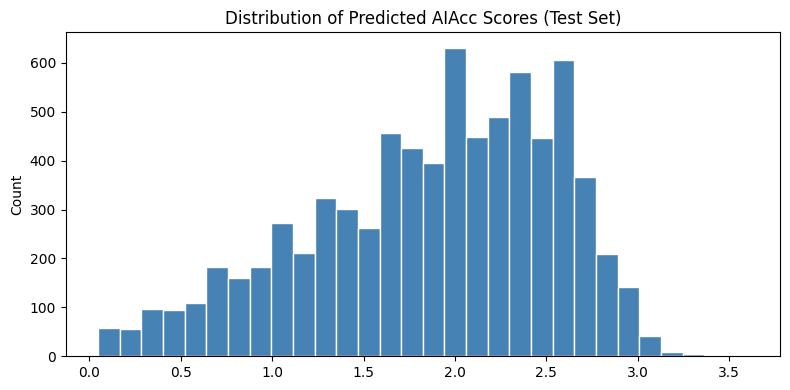

In [16]:
# Distribution of predicted trust scores
plt.figure(figsize=(8, 4))
plt.hist(y_pred, bins=30, color='steelblue', edgecolor='white')
plt.ylabel('Count')
plt.title('Distribution of Predicted AIAcc Scores (Test Set)')
plt.tight_layout()
plt.show()

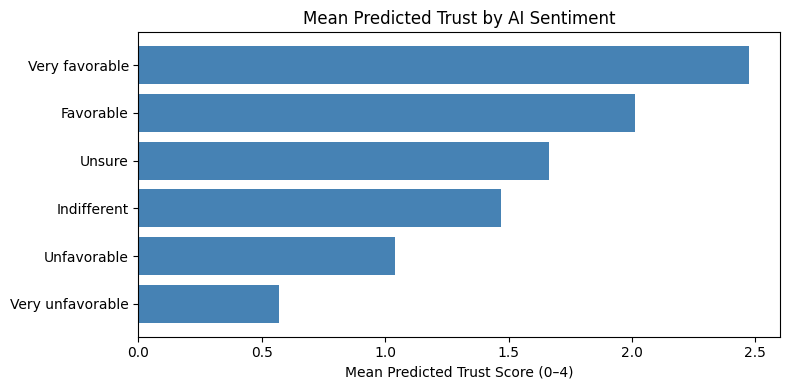

In [17]:
# Mean predicted trust by AI sentiment
aisant_means = df_results.groupby('AISent')['predicted_AIAcc'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(aisant_means.index, aisant_means.values, color='steelblue')
ax.set_xlabel('Mean Predicted Trust Score (0–4)')
ax.set_title('Mean Predicted Trust by AI Sentiment')
plt.tight_layout()
plt.show()

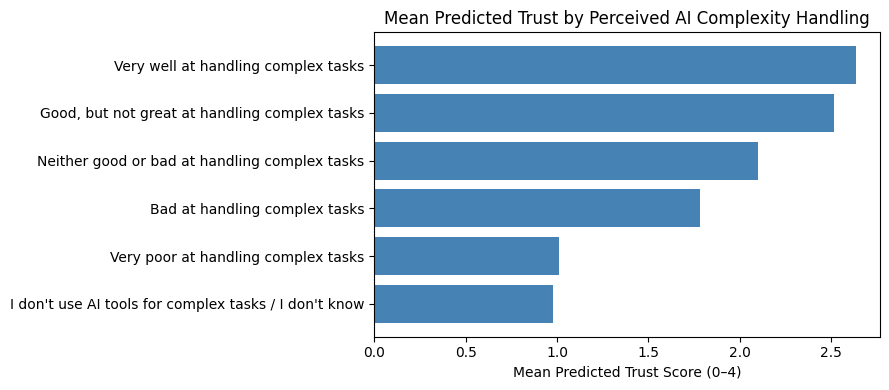

In [18]:
# Mean predicted trust by perceived AI complexity handling
aicomplex_means = df_results.groupby('AIComplex')['predicted_AIAcc'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(aicomplex_means.index, aicomplex_means.values, color='steelblue')
ax.set_xlabel('Mean Predicted Trust Score (0–4)')
ax.set_title('Mean Predicted Trust by Perceived AI Complexity Handling')
plt.tight_layout()
plt.show()

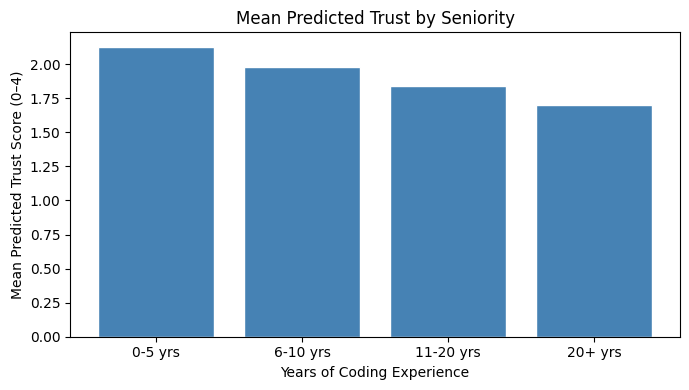

In [20]:
# Mean predicted trust by seniority
seniority_means = df_results.groupby('seniority', observed=True)['predicted_AIAcc'].mean()

plt.figure(figsize=(7, 4))
plt.bar(seniority_means.index, seniority_means.values, color='steelblue', edgecolor='white')
plt.xlabel('Years of Coding Experience')
plt.ylabel('Mean Predicted Trust Score (0–4)')
plt.title('Mean Predicted Trust by Seniority')
plt.tight_layout()
plt.show()

Things to note:

1. The biggest limitation of this model is mean compression. Because CF predicts by averaging neighbor ratings, predictions tend to cluster between 1.5 and 2.5 on the 0-4 scale regardless of the true value. The model rarely predicts extreme trust or extreme distrust. This is a well known issue with weighted average CF and it is important to keep in mind when interpreting the results. Despite this, binary accuracy still hits 76.55% which is competitive with the neural network.

2. AI sentiment is the strongest signal the model picks up on. Developers with very unfavorable AI sentiment get a mean predicted trust score of 0.57, while developers with very favorable sentiment average 2.48. That is nearly a 2 point spread on a 4 point scale and is by far the largest difference we see across any feature. This lines up with what the Bayesian model found as well.

3. How developers perceive AI capability also matters a lot. Developers who think AI handles complex tasks very poorly average a predicted trust score of 1.01, while those who think it handles them very well average 2.64. The more competent a developer thinks AI is, the more they tend to trust its output.

4. More experienced developers tend to trust AI less. The correlation between years of coding experience and predicted trust is -0.19, and developers with 20+ years of experience average a predicted score of 1.70 compared to 2.13 for those with 0-5 years. Senior developers appear to be more skeptical of AI output accuracy, which makes intuitive sense.

5. The CF and Bayesian models agree on what matters most. Both models independently point to AI sentiment and perceived AI complexity handling as the primary drivers of trust. Getting consistent results from two very different methods strengthens the overall conclusion that these two variables are the key factors.